# I. Xử lý văn bản - Tokenization, Stemming, Lemmatization

## 1. Tại sao cần xử lý văn bản (Text Preprocessing)?

Trong thế giới thực, dữ liệu ngôn ngữ tự nhiên do con người tạo ra thường rất lộn xộn, thiếu cấu trúc và chứa nhiều thành phần dư thừa. Máy tính không thể trực tiếp đọc hiểu một đoạn văn bản thô giống như con người. Việc tiền xử lý văn bản là bước bắt buộc và mang tính sống còn, dựa trên 3 lý do cốt lõi sau:

- **Làm sạch dữ liệu để loại bỏ nhiễu:** Một văn bản thu thập từ Internet thường chứa các ký tự đặc biệt, dấu câu, thẻ HTML, đường dẫn link, hoặc các lỗi sai chính tả. Hơn nữa, ngôn ngữ chứa rất nhiều "Stop words" (từ dừng) như "a", "the", "is" trong tiếng Anh hay "thì", "là", "mà" trong tiếng Việt. Việc loại bỏ các yếu tố này giúp mô hình không bị xao nhãng, tập trung tài nguyên tính toán vào các từ vựng mang ý nghĩa thực sự của câu.
- **Giảm chiều dữ liệu (Dimensionality Reduction):** Trong học máy, mỗi từ vựng độc lập thường được biểu diễn thành một chiều không gian (trục tọa độ). Ngôn ngữ có tính biến thể rất cao (ví dụ: *run, runs, running, ran*). Nếu ta coi mỗi biến thể là một từ mới, bộ từ điển sẽ phình to ra tới hàng triệu từ. Việc đưa các biến thể này về chung một gốc từ (*run*) giúp thu gọn đáng kể kích thước từ điển, giải phóng bộ nhớ RAM và giúp mô hình học các quy luật nhanh hơn, tránh hiện tượng quá khớp (overfitting).
- **Chuẩn hóa đầu vào:** Ngôn ngữ của con người là vô hạn (có thể ghép thành vô số câu), nhưng máy tính chỉ xử lý được các con số hữu hạn. Tiền xử lý giúp bẻ gãy thế giới ngôn ngữ vô hạn đó thành một tập hợp các phần tử tiêu chuẩn, thống nhất. Đây là bước đệm bắt buộc trước khi chuyển đổi chữ viết sang ma trận số học (Vectorization) để đưa vào các mạng nơ-ron nhân tạo.

## 2. Tokenization là gì và các phương pháp phổ biến

**Tokenization** (Tách từ/Tách chuỗi) là quá trình chia một đoạn văn bản dài thành các mảnh ghép nhỏ hơn, có ý nghĩa cơ sở. Các mảnh ghép này được gọi là các **token**. Tùy vào cách chúng ta chọn "mảnh ghép" to hay nhỏ, ta có 3 phương pháp Tokenization chính:

### Mức độ từ (Word-level Tokenization)

- **Cách thức hoạt động:** Phương pháp này sử dụng các dấu phân cách rõ ràng như khoảng trắng (space) và dấu câu để cắt văn bản. Ví dụ: Câu `"I love NLP"` sẽ được tách thành danh sách `["I", "love", "NLP"]`.
- **Ưu điểm:** Cách tách này rất trực quan, dễ hiểu và giữ nguyên được ngữ nghĩa trọn vẹn của một từ giống như cách con người tư duy.
- **Nhược điểm chí mạng:**
  - Gặp vấn đề **OOV (Out-of-Vocabulary - Từ ngoài từ điển)**: Khi triển khai thực tế, nếu người dùng nhập một từ mới mà mô hình chưa từng thấy trong lúc huấn luyện (ví dụ: mô hình biết *fast* nhưng chưa từng gặp *fastest*), hệ thống sẽ báo lỗi và không hiểu được.
  - Bất lực với ngôn ngữ viết dính liền (tiếng Trung, tiếng Nhật không dùng khoảng trắng).
  - Phá vỡ ngữ nghĩa của từ ghép trong tiếng Việt (ví dụ: từ "học sinh" bị tách sai thành hai token độc lập là "học" và "sinh").

### Mức độ ký tự (Character-level Tokenization)

- **Cách thức hoạt động:** Đập vụn toàn bộ câu thành từng chữ cái đơn lẻ. Ví dụ: `"NLP"` $\rightarrow$ `["N", "L", "P"]`.
- **Ưu điểm:** Giải quyết triệt để 100% vấn đề OOV. Vì bộ từ điển giờ đây chỉ bao gồm khoảng vài chục ký tự trong bảng chữ cái, máy tính có thể lắp ghép và đọc được bất kỳ từ nào trên đời dù có sai chính tả.
- **Nhược điểm:** Từng chữ cái đứng một mình không hề mang ý nghĩa ngữ nghĩa (chữ "N" không có nghĩa là ngôn ngữ). Đồng thời, phương pháp này làm chuỗi đầu vào trở nên quá dài. Một câu 20 từ có thể biến thành một chuỗi 100 ký tự, khiến các mô hình học sâu rất khó nhớ được ngữ cảnh từ đầu đến cuối câu.

### Mức độ từ phụ (Subword-level Tokenization)

- **Cách thức hoạt động:** Đây là giải pháp cân bằng và thông minh nhất hiện nay, hoạt động dựa trên toán học thống kê. Nó không dùng khoảng trắng, cũng không đập nát thành chữ cái. Nó quét qua dữ liệu khổng lồ, tìm ra các **cụm ký tự xuất hiện thường xuyên nhất** để tách. Những từ phổ biến sẽ được giữ nguyên, còn những từ hiếm/dài sẽ bị cắt thành các âm tiết nhỏ. Ví dụ: `"unhappiness"` $\rightarrow$ `["un", "happi", "ness"]`.
- **Đặc điểm nổi bật:** Khắc phục được lỗi OOV của Word-level, đồng thời không làm mất ý nghĩa và không làm chuỗi quá dài như Character-level. Các thuật toán nổi tiếng như BPE (Byte-Pair Encoding) hay WordPiece chính là lõi công nghệ đằng sau các siêu AI hiện đại như ChatGPT (GPT-4) và BERT.

## 3. Phân tích Stemming và Lemmatization

Sau khi chia nhỏ câu thành các token, bài toán tiếp theo là phải gom các từ có chung ý nghĩa nhưng khác biệt về mặt hình thái (số nhiều, chia thì động từ) về một dạng gốc chung. Chúng ta có hai trường phái tiếp cận vấn đề này.

### Phân tích phương pháp Stemming 

Stemming hoạt động giống như một cỗ máy xử lý văn bản dựa trên các **bộ quy tắc (rule-based) cứng nhắc**. Nó hoàn toàn mù tịt về ngữ pháp và không có bất kỳ cuốn từ điển nào trong hệ thống.

- **Cơ chế:** Thuật toán (ví dụ: Porter Stemmer) chỉ đơn giản là tìm các đuôi phổ biến như `-ing`, `-ed`, `-ly`, `-es` và chặt bỏ chúng đi.
- **Ưu điểm:** Vô cùng nhẹ và xử lý với tốc độ chớp nhoáng. Thích hợp cho các bài toán xử lý lượng dữ liệu khổng lồ nơi tốc độ quan trọng hơn độ chính xác tuyệt đối (như công cụ tìm kiếm - Search Engine).
- **Hạn chế:** Vì cắt "mù quáng", nó thường xuyên tạo ra những cụm ký tự vô nghĩa, không tồn tại trong tiếng Anh. Ví dụ, nó sẽ cắt đuôi từ `caring` (quan tâm) biến thành `car` (cái ô tô), hoặc cắt từ `wolves` (những con sói) biến thành `wolv`.

### Phân tích phương pháp Lemmatization (Tra cứu ngôn ngữ học)

Khác với sự thô bạo của Stemming, Lemmatization hoạt động giống như một nhà ngôn ngữ học thực thụ. Phương pháp này được liên kết với một cơ sở dữ liệu từ điển khổng lồ (như WordNet).

- **Cơ chế:** Để biến đổi một từ, nó sẽ thực hiện phân tích cấu trúc hình thái học. Nó đối chiếu từ đó cùng với **từ loại của nó trong câu (Part-of-Speech - POS)** để tìm ra gốc từ chuẩn xác (được gọi là *lemma*).
- **Ưu điểm:** Độ chính xác ngữ nghĩa cực cao. Dù đối mặt với các từ bất quy tắc, nó vẫn xử lý hoàn hảo (ví dụ: nó biết `better` và `best` đều xuất phát từ gốc `good`; `mice` đổi thành `mouse`). Kết quả trả về **luôn luôn là một từ có thật và có nghĩa**.
- **Hạn chế:** Tốc độ chậm hơn Stemming rất nhiều vì phải trải qua bước phân tích ngữ cảnh (nhận diện danh từ, động từ) và tốn thời gian tra cứu từ điển.

### Bảng so sánh tổng kết

| **Tiêu chí**         | **Stemming**                                                                                   | **Lemmatization**                                                                                                        |
| -------------------- | ---------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| **Cách hoạt động**   | Cắt bỏ các tiền tố/hậu tố ở đầu hoặc cuối từ một cách máy móc theo bộ luật.                    | Sử dụng từ vựng học và phân tích hình thái học để tìm ra từ gốc thực sự.                                                 |
| **Độ chính xác**     | Thấp. Kết quả đôi khi tạo ra một từ bị cụt, không có nghĩa (VD: `caring` $\rightarrow$ `car`). | Cao. Luôn trả về một từ có nghĩa chuẩn trong từ điển (VD: `caring` $\rightarrow$ `care`, `better` $\rightarrow$ `good`). |
| **Tốc độ**           | Rất nhanh (vì chỉ dùng luật heuristic cắt chuỗi).                                              | Chậm hơn (vì phải tra cứu từ điển và đối chiếu ngữ cảnh/từ loại).                                                        |
| **Yêu cầu ngữ cảnh** | Xử lý từ độc lập, không quan tâm vị trí của từ trong câu.                                      | Cần biết rõ từ loại (Danh từ, Động từ...) để tra gốc chính xác nhất.                                                     |
| **Khi nào sử dụng?** | Các hệ thống cần tốc độ quét dữ liệu siêu nhanh (Search Engine, Information Retrieval).        | Các bài toán đòi hỏi độ tinh tế và hiểu ngữ nghĩa sâu sắc (Chatbot, Dịch máy, Phân tích cảm xúc). |

# II. Bag of Words, TF-IDF, và Biểu diễn văn bản


## 1. Tại sao phải biểu diễn văn bản sang số?

Bản chất của các thuật toán Học máy (Machine Learning) và Trí tuệ nhân tạo (AI) là các hàm toán học tối ưu hóa trên không gian nhiều chiều. Chúng không có "mắt" để đọc chuỗi ký tự hay "não" để hiểu cấu trúc ngữ pháp.

Việc chuyển đổi chữ sang số (Text Vectorization) là bước bắt buộc để biến dữ liệu định tính (văn bản) thành dữ liệu định lượng (các vector và ma trận số). Chỉ khi đó, máy tính mới có thể thực hiện các phép tính đại số tuyến tính để đo lường khoảng cách ngữ nghĩa hoặc phân loại cảm xúc.

> **Lý thuyết cốt lõi:** Dựa trên *Mô hình Không gian Vector (Vector Space Model)*, mỗi văn bản sẽ biến thành một điểm tọa độ toán học. Nhờ đó, AI có thể tính toán xem hai văn bản có "nằm gần nhau" trong không gian hay không để suy ra độ tương đồng ý nghĩa.

---

## 2. Cấu trúc học thuật của Bag of Words và TF-IDF

Để thực hiện quá trình số hóa, các nhà khoa học máy tính sử dụng hai phương pháp cơ bản:

- **Bag of Words (BoW):** Phá vỡ toàn bộ cấu trúc ngữ pháp và thứ tự từ. Thuật toán tạo ra một "bộ từ vựng" chứa tất cả các từ, sau đó đếm số lần xuất hiện của mỗi từ trong từng văn bản. Nhược điểm của nó là đánh giá quá cao các từ phổ biến nhưng vô nghĩa.


- **TF-IDF (Term Frequency - Inverse Document Frequency):** Khắc phục lỗi của BoW bằng cách sử dụng *Lý thuyết Thông tin*. Nó giữ nguyên tần suất cục bộ (TF), nhưng nhân thêm một hệ số phạt toàn cục (IDF) đối với các từ xuất hiện ở mọi văn bản.

  - **Công thức toán học:**

$$
W_{i,j} = TF_{i,j} \times \log\left(\frac{N}{DF_i}\right)
$$

  - Trong đó:
    - $N$ là tổng số văn bản.
    - $DF_i$ là số văn bản chứa từ khóa $i$.
    - $TF_{i,j}$ là số lần từ $i$ xuất hiện trong văn bản $j$.
    - $W_{i,j}$ là trọng số TF-IDF của từ $i$ trong văn bản $j$.


### 3. Ví Dụ

- **Câu 1:** "mèo bắt chuột và mèo ăn cá" (Chữ "mèo" lặp lại 2 lần)
- **Câu 2:** "chó sủa gâu gâu khi thấy chuột" (Chữ "gâu" lặp lại 2 lần)
- **Câu 3:** "trâu ăn cỏ và trâu uống nước" (Chữ "trâu" lặp lại 2 lần)

---


**a. Xây dựng bộ từ vựng (Khung chuẩn)**

Đầu tiên, hệ thống BoW sẽ gom tất cả các từ riêng biệt từ 3 câu trên để tạo thành một "từ điển" chung.

Chúng ta có tổng cộng 15 từ riêng biệt:

- **Bộ từ vựng:** `["mèo", "bắt", "chuột", "và", "ăn", "cá", "chó", "sủa", "gâu", "khi", "thấy", "trâu", "cỏ", "uống", "nước"]`

**b. Biểu diễn Vector BoW (Đếm tần suất)**

Thuật toán BoW cực kỳ đơn giản: Nó chỉ lướt qua từng câu và đếm số lần xuất hiện của từng từ dựa trên bộ từ vựng chuẩn ở trên. Nó không quan tâm từ đó hiếm hay phổ biến.

- **Vector Câu 1:** `[2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]`

  (Chữ "mèo" xuất hiện 2 lần nên mang giá trị 2; "bắt", "chuột", "và", "ăn", "cá" mang giá trị 1; các từ của con chó và con trâu không có nên mang giá trị 0).

- **Vector Câu 2:** `[0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 1, 0, 0, 0, 0]`

  (Chữ "gâu" đếm được 2 lần nên mang giá trị 2; các từ "chuột", "chó", "sủa", "khi", "thấy" mang giá trị 1).

- **Vector Câu 3:** `[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1]`

  (Chữ "trâu" mang giá trị 2; "và", "ăn", "cỏ", "uống", "nước" mang giá trị 1).

---

 **c. Mô hình TF-IDF**

1. **Từ "ăn":** Xuất hiện 1 lần trong Câu 1 ($TF = 1$), có mặt ở tổng cộng 2 câu ($DF = 2$).

   $\rightarrow \text{Điểm} = 1 \times \log_{10}\left(\frac{3}{2}\right) \approx 1 \times 0.176 = \mathbf{0.176}$

2. **Từ "chuột":** Xuất hiện 1 lần trong Câu 1 ($TF = 1$), có mặt ở tổng cộng 2 câu ($DF = 2$).

   $\rightarrow \text{Điểm} = 1 \times \log_{10}\left(\frac{3}{2}\right) \approx 1 \times 0.176 = \mathbf{0.176}$

3. **Từ "cá":** Xuất hiện 1 lần trong Câu 1 ($TF = 1$), chỉ có mặt ở 1 câu ($DF = 1$).

   $\rightarrow \text{Điểm} = 1 \times \log_{10}\left(\frac{3}{1}\right) \approx 1 \times 0.477 = \mathbf{0.477}$

4. **Từ "mèo":** Được tác giả nhấn mạnh lặp lại 2 lần trong Câu 1 ($TF = 2$), chỉ có mặt ở 1 câu ($DF = 1$).

   $\rightarrow \text{Điểm} = 2 \times \log_{10}\left(\frac{3}{1}\right) \approx 2 \times 0.477 = \mathbf{0.954}$

   
**Vector Câu 1 =** `[0.954, 0.477, 0.176, 0.176, 0.176, 0.477, 0, 0, 0, 0, 0, 0, 0, 0, 0]`


---

### 4. Nhận xét và So sánh kết quả

Nhìn vào cách hai thuật toán xử lý **Câu 1**, chúng ta thấy rõ điểm yếu của BoW và sự tinh tế của TF-IDF:

- **Trong BoW:** Từ "mèo" (được đếm 2 lần) có giá trị là 2. Nhưng giả sử từ nối vô nghĩa "và" cũng bị lặp lại 2 lần trong câu, nó cũng sẽ có giá trị là 2. BoW đánh đồng tất cả mọi từ vựng, miễn là chúng xuất hiện nhiều.

- **Trong TF-IDF:** Nếu nhìn bằng mắt thường, AI sẽ nhận thấy sự phân cấp rõ ràng:
  - Từ **"ăn"** (0.176) bị điểm thấp vì nó là từ khá phổ biến (xuất hiện cả ở câu của con trâu).
  - Từ **"cá"** (0.477) là một từ hiếm, đặc trưng cho câu này nên được điểm cao.
  - **Sự bùng nổ của từ "mèo" (0.954):** Từ "mèo" vừa là từ hiếm (chỉ xuất hiện ở Câu 1, IDF cao), lại vừa được lặp lại 2 lần ($TF = 2$). Phép nhân tạo ra một số điểm áp đảo, giúp AI lập tức dán nhãn: *"Chủ đề chính xác của câu này là về con MÈO!"*


# III. Word Embeddings
## 1. Trước khi Word Embeddings ra đời

Trước khi Word Embeddings ra đời, các mô hình NLP truyền thống thường dùng **Bag-of-Words (BoW)** hoặc **TF-IDF (Term Frequency - Inverse Document Frequency)** để biểu diễn văn bản. Tuy nhiên, phương pháp này tồn tại **3 nhược điểm cốt lõi**:

 **a. Thiếu ngữ nghĩa và mối liên hệ từ vựng**

Các vector trong TF-IDF mang tính trực giao (orthogonal). Dù "xe hơi" và "ô tô" là từ đồng nghĩa, máy tính vẫn coi chúng là hai mã ID hoàn toàn xa lạ. Tích vô hướng (khoảng cách) giữa vector "xe hơi" và "ô tô" trong không gian TF-IDF luôn bằng 0, giống hệt như khoảng cách giữa "xe hơi" và "con chó".

**b. Vector thưa (Sparse Vector) và số chiều khổng lồ**

Kích thước của một vector TF-IDF bằng đúng số lượng từ vựng trong từ điển (vocabulary size - $\vert{}V\vert{}$). Một tập dữ liệu vừa phải có thể có $\vert{}V\vert{} = 100,000$, tạo ra những vector chứa 99.9% là số 0. Điều này gây tốn bộ nhớ và dễ dẫn đến hiện tượng **"lời nguyền số chiều" (curse of dimensionality)**.

**c. Không nắm bắt được thứ tự từ**

TF-IDF chỉ quan tâm đến tần suất từ xuất hiện trong văn bản mà không quan tâm chúng đứng ở đâu, cạnh từ nào. Do đó, nó không phân biệt được ý nghĩa thay đổi khi ngữ cảnh thay đổi, do đó **"Chó cắn người"** và **"Người cắn chó"** sẽ có chung một biểu diễn vector.

---

## 2. Embedding là gì?

Embedding là một kỹ thuật đưa một vector có số chiều lớn, thường ở dạng thưa, về một vector có số chiều nhỏ, thường ở dạng dày đặc. Phương pháp này đặc biệt hữu ích với những đặc trưng hạng mục có số phần tử lớn ở đó phương pháp chủ yếu để biểu diễn mỗi giá trị thường là một vector dạng one-hot. Một cách lý tưởng, các giá trị có ý nghĩa tương tự nhau nằm gần nhau trong không gian embedding.

Ví dụ nổi bật nhất là biểu diễn các từ trong một bộ từ điển dưới dạng số. Khi từ điển có hàng triệu từ, biểu diễn các từ dưới dạng one-hot vector dẫn tới số chiều vô cùng lớn. Hơn nữa, các từ này sẽ có khoảng cách đều nhau tới mọi từ khác (căn bậc hai của 2), dẫn đến việc thiếu thông tin giá trị cho việc huấn luyện mô hình machine learning. Chẳng hạn, một cách biểu diễn tốt các từ tiếng Việt cần mô tả tốt sự liên quan giữa cặp từ (vua, hoàng hậu) và (chồng, vợ) vì chúng có ý nghĩa gần nhau.

---

## 3. Quy trình 4 bước tạo ra Embeddings

Để biến một câu văn bình thường thành các vector có ý nghĩa như trên, hệ thống cần thực hiện lần lượt **4 bước**:

### 3.1. Bước 1: Token hóa (Tokenization)

Tách câu hoàn chỉnh thành các đơn vị nhỏ nhất (từ hoặc cụm từ).

**Ví dụ:** Câu **"Tôi yêu học máy"** sẽ bị cắt nhỏ thành danh sách **["Tôi", "yêu", "học", "máy"]**.

### 3.2. Bước 2: Tạo từ điển

Cấp cho mỗi từ vừa cắt ra một mã định danh (chỉ số) duy nhất để máy tính dễ quản lý.

**Ví dụ:** `{"Tôi": 0, "yêu": 1, "học": 2, "máy": 3}`.

### 3.3. Bước 3: Ánh xạ từ sang vector

Áp dụng các mô hình ngôn ngữ (như Word2Vec, GloVe) để thay thế mỗi từ bằng một vector số học khởi tạo.

**Ví dụ:** Từ **"Tôi"** trở thành `[0.1, 0.3, 0.5]`.

### 3.4. Bước 4: Học Embeddings

Đây là bước tinh chỉnh then chốt. Mô hình học máy sẽ đọc các văn bản, phân tích ngữ cảnh xuất hiện của từ ngữ, và liên tục điều chỉnh các con số bên trong vector. Mục tiêu cuối cùng là ép các từ có ý nghĩa giống nhau phải xích lại gần nhau trong không gian đa chiều.

---

## 4. Embeddings khắc phục điểm yếu của TF-IDF như thế nào?

Embeddings chính là chìa khóa để xử lý triệt để **3 "tử huyệt" của TF-IDF** đã nêu ở Phần 1, cụ thể như sau:

### 4.1. Khắc phục sự thưa thớt và giảm số chiều khổng lồ

Thay vì tạo ra vector chứa hàng trăm nghìn số 0 vô nghĩa, Embeddings nén thông tin từ vựng thành các vector **"dày đặc" (dense vectors)**. Các vector này có kích thước cố định, rất nhỏ gọn (thường từ 50 đến 300 chiều), và mọi con số đều là số thực mang giá trị. Việc này giải phóng hoàn toàn gánh nặng lưu trữ và tăng tốc độ tính toán cho mô hình.

### 4.2. Khắc phục sự "mù" ngữ nghĩa bằng hình học không gian

Bằng cách ánh xạ từ ngữ thành các tọa độ, Embeddings ép các từ có chung ngữ nghĩa (như **"xe hơi"** và **"ô tô"**) xích lại gần nhau. Khoảng cách (ví dụ như Cosine Similarity) giữa chúng sẽ vô cùng nhỏ. Máy tính nhờ đó mà "nhìn" ra được sự đồng nghĩa hoặc các mối quan hệ logic phức tạp giữa các từ.

### 4.3. Khắc phục việc bỏ qua ngữ cảnh

Để học được các con số trong vector, các thuật toán (như Word2Vec) không dựa vào việc đếm số lần xuất hiện rời rạc. Chúng huấn luyện bằng cách trượt qua từng câu, dùng từ trung tâm để dự đoán các từ xung quanh (hoặc ngược lại). Chính cơ chế này giúp "nhúng" (embed) toàn bộ DNA ngữ cảnh thực tế vào bên trong cấu trúc của vector.


# IV. Word2Vec
 
## 1. Tại sao cần phải dùng Word2Vec và Ý tưởng cốt lõi của nó là gì?

**Word2vec** là một mô hình đơn giản và nổi tiếng giúp tạo ra các biểu diễn embedding của từ trong một không gian có số chiều thấp hơn nhiều lần so với số từ trong từ điển. Sức mạnh của ý tưởng này lớn đến mức nó không chỉ giới hạn trong xử lý ngôn ngữ tự nhiên mà còn được ứng dụng cho các dạng dữ liệu khác xa với ngôn ngữ (như tạo embedding cho các sản phẩm, ví dụ: bài toán Product2vec).

**Ý tưởng cơ bản của Word2vec được đúc kết qua hai điểm cốt lõi:**

- **Hai từ xuất hiện trong những văn cảnh giống nhau thường có ý nghĩa gần với nhau.**
- **Ta hoàn toàn có thể đoán được một từ nếu biết các từ xung quanh nó trong câu.** Xét câu văn: “Hà Nội là … của Việt Nam”, từ bị khuyết trong dấu ba chấm khả năng cao nhất là “thủ đô”. Nhiệm vụ của mô hình word2vec là xây dựng ra các embedding sao cho xác suất để dự đoán đúng từ “thủ đô” đạt mức cao nhất.

---

## 2. Giải thích kỹ về Ma trận U và V: Sinh ra để làm gì?

Trong một câu văn, mô hình sẽ xác định một **"từ đích"** (target word - từ trung tâm đang xét) và các **"từ ngữ cảnh"** (context words - các từ xung quanh cách từ đích một khoảng không quá $C/2$).

Word2vec định nghĩa hai embedding vector cùng chiều cho mỗi một từ $w$ trong từ điển:

- Khi từ đó đóng vai trò là **từ đích**, embedding vector của nó là $u$.
- Khi từ đó đóng vai trò là **từ ngữ cảnh**, embedding vector của nó là $v$.

Sở dĩ bài toán cần sinh ra hai embedding khác nhau vì ý nghĩa và vai trò của một từ khi làm tâm điểm dự đoán so với khi làm nền ngữ cảnh là hoàn toàn khác biệt. Tương ứng với hai vector này, toàn bộ mạng neural sở hữu hai ma trận trọng số độc lập: **Ma trận $U$ dành cho các từ đích và Ma trận $V$ dành cho các từ ngữ cảnh.**

**(Giải thích chi tiết cấu tạo ma trận):**

- **Ma trận U (Kích thước $V \times N$):** Mỗi hàng (row) đại diện cho một từ duy nhất khi nó đóng vai trò là "Từ trung tâm". Mỗi cột (column) là một chiều đặc trưng ẩn của từ đó. Ma trận U đóng vai trò như một bảng tra cứu, sau khi huấn luyện xong sẽ chính là bộ Word Embeddings.
- **Ma trận V (Kích thước $N \times V$):** Mỗi cột (column) đại diện cho một từ duy nhất khi nó lùi về làm "Từ ngữ cảnh". Mỗi hàng (row) tương ứng với một chiều đặc trưng ẩn để nhân vô hướng với ma trận U. Ma trận V chỉ là "giàn giáo" phục vụ chấm điểm và sẽ bị vứt bỏ sau khi huấn luyện.

---

## 3. Phân tích 2 kiến trúc đối lập: Skip-gram và CBOW

Tùy thuộc vào cách mô hình hóa dữ liệu, Word2Vec phân chia thành hai phương pháp với ưu nhược điểm riêng biệt. Sự khác biệt cốt lõi nhất nằm ở chiều dự đoán **(1 đoán nhiều hay nhiều đoán 1):**

**a. Kiến trúc Skip-gram (Dùng 1 đoán nhiều):**

**Nguyên lý:** Đảo ngược quá trình suy luận, Skip-gram đi dự đoán những từ ngữ cảnh nếu biết trước từ đích. Nó xé lẻ cửa sổ trượt ra thành các cặp 1-1 hoàn toàn độc lập (từ trung tâm - từ ngữ cảnh 1; từ trung tâm - từ ngữ cảnh 2,...).

**Đặc điểm:** Skip-gram làm việc cực kỳ tốt với dữ liệu nhỏ và biểu diễn rất tốt những từ có tần suất xuất hiện thấp (từ hiếm). Việc này vô cùng hợp lý về mặt toán học vì với một từ đích hiếm, mô hình vẫn xé nhỏ bối cảnh để xây dựng được nhiều mẫu huấn luyện xung quanh từ đó.

**b. Kiến trúc CBOW (Continuous Bag of Words - Dùng nhiều đoán 1):**

**Nguyên lý:** Dựa vào những từ ngữ cảnh để dự đoán ra một từ đích duy nhất ở trung tâm. Vì có nhiều từ ngữ cảnh làm điều kiện, thuật toán đơn giản hóa chúng bằng cách lấy một từ “trung bình” làm đại diện (tính trung bình cộng của các embedding ngữ cảnh).

**Đặc điểm:** CBOW lại vô cùng phù hợp với các bộ dữ liệu khổng lồ. Do gom chung ngữ cảnh lại thành một vòng tính toán duy nhất, số mẫu huấn luyện được tạo ra từ mỗi bối cảnh ít hơn nhiều so với Skip-gram. Nhờ đó, tốc độ chạy được đẩy lên cao và mô hình biểu diễn rất tốt các từ xảy ra thường xuyên.

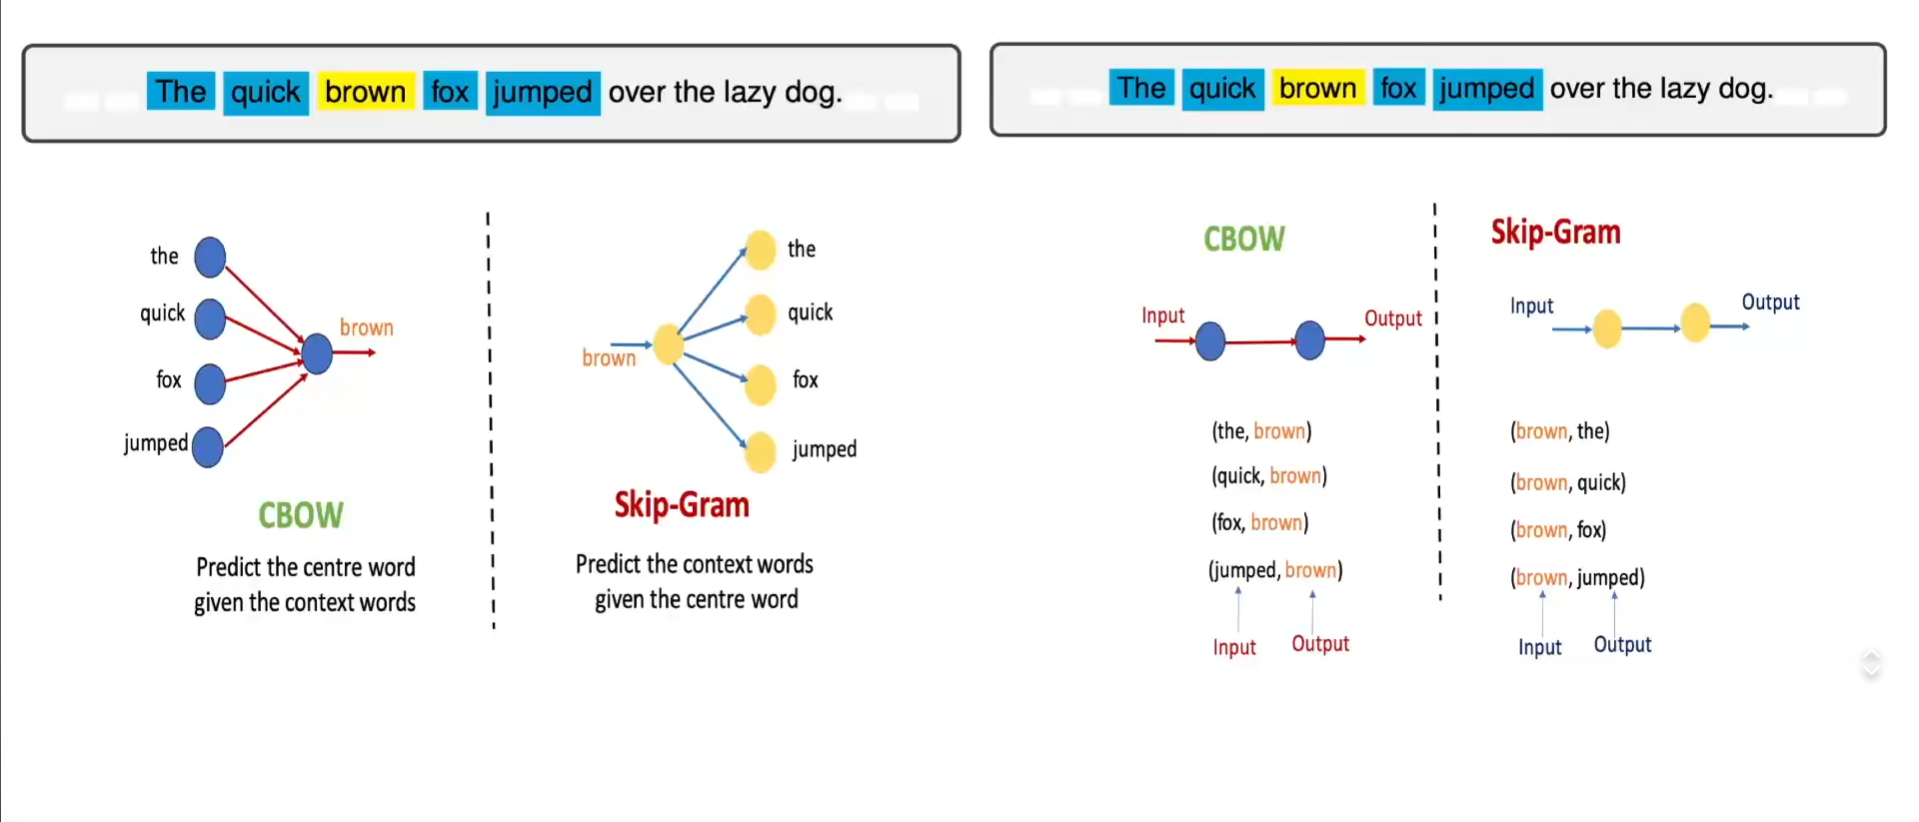

---

## 4. Cấu trúc mạng Neural và Lan truyền xuôi (Forward Pass)

Kiến trúc mạng neural của Word2Vec vô cùng đơn giản với đặc điểm nổi bật là **chỉ có một tầng ẩn và hoàn toàn không có hàm kích hoạt tại tầng ẩn này.**(Làm rõ quy trình lan truyền xuôi):

**a. Lớp Đầu vào (Input Layer):**

Về mặt lý thuyết toán học, đầu vào không phải là các con số ID đơn thuần mà là các vector One-hot (vector có kích thước $V$ bằng toàn bộ từ điển, chứa toàn số $0$ và chỉ có một số $1$ ở vị trí của từ đó).

Đối với kiến trúc Skip-gram, hệ thống nhận một vector One-hot $x$ đại diện cho 1 từ trung tâm duy nhất đang được xét.

Đối với CBOW, hệ thống nhận nhiều vector One-hot $x_1, x_2, \dots$ đại diện cho nhiều từ ngữ cảnh xung quanh lọt vào trong cửa sổ trượt cùng một lúc.

**b. Tầng Ẩn (Hidden Layer - Chứa ma trận U):**

Đối với kiến trúc Skip-gram, hệ thống thực hiện phép nhân ma trận giữa vector One-hot $x$ của từ đích với ma trận trọng số $U$. Kết quả thu được ($h = U^T x$) chính là vector đặc trưng $u_t$ của từ đó tại tầng ẩn. (Lưu ý: Mặc dù lý thuyết là phép nhân vector One-hot, nhưng trong thực tế lập trình, người ta dùng Token ID để "cắt" thẳng dòng tương ứng ra nhằm tiết kiệm RAM).

Đối với CBOW, hệ thống nhân các vector One-hot đầu vào với ma trận $U$ để rút ra các vector tương ứng, sau đó bắt buộc phải cộng trung bình (average) tất cả các vector embedding thuộc các từ ngữ cảnh này lại thành một vector gộp duy nhất:

$$
\bar{u} = \frac{1}{C}\sum U^T x_i
$$

**c. Lớp Đầu ra (Output Layer - Chứa ma trận V):**

Đầu ra của tầng ẩn (không đi qua hàm kích hoạt) sẽ được nhân trực tiếp với ma trận trọng số đầu ra $V$ để thu được giá trị $u_t^T V$. Đây chính là vector logit thô mang điểm số tương đồng trước khi được đẩy vào hàm kích hoạt ở bước cuối cùng.

## 5. Tối ưu hàm mất mát và Vấn đề chí mạng:
Kiến trúc tinh giản này giúp mạng có thể hoạt động ngay cả khi kích thước đầu vào và đầu ra (số lượng từ trong từ điển) lên tới con số nhiều triệu từ. **Xây dựng hàm mất mát gốc (Từ Xác suất đến Negative Log Loss):**

Từ dữ liệu đã có, mục tiêu cốt lõi của mô hình là tối đa hóa xác suất xuất hiện của toàn bộ tập từ ngữ cảnh (ký hiệu là tập $C_t$) khi biết trước từ đích $w_t$. Xác suất đồng thời này được biểu diễn bằng phép nhân:

$$
\prod_{c \in C_t} P(w_c \mid w_t)
$$

Tuy nhiên, việc nhân liên tiếp các số xác suất (nhỏ hơn 1) với nhau sẽ dẫn đến hiện tượng tràn số dưới (underflow - sai số tính toán nghiêm trọng của máy tính). Để khắc phục, bài toán được biến đổi bằng cách lấy logarit và đảo dấu, đưa về dạng tối thiểu hóa hàm Negative Log Loss:

$$
-\sum_{c \in C_t} \log P(w_c \mid w_t)
$$

Trong đó, xác suất có điều kiện $P(w_c \mid w_t)$ được định nghĩa thông qua hàm Softmax để đảm bảo tổng xác suất của cả từ điển bằng 1:

$$
P(w_c \mid w_t)
=
\frac{\exp(u_t^T v_c)}
{\sum_{i=1}^N \exp(u_t^T v_i)}
$$

(Với $N$ là số lượng từ trong từ điển $V$. Giá trị $\exp(u_t^T v_c)$ càng cao thì xác suất tương đồng giữa hai vector càng lớn).

Tóm lại, khi ghép các thành phần lại, ta thu được công thức hàm mất mát tổng quát ứng với từ đích $w_t$ theo hai ma trận trọng số $U, V$ là:

$$
L(U,V;w_t)
=
-\sum_{c \in C_t}
\log\left(
\frac{\exp(u_t^T v_c)}
{\sum_{i=1}^N \exp(u_t^T v_i)}
\right)
$$


Để tối ưu hàm mất mát này bằng thuật toán Gradient Descent, ta khai triển biểu thức logarit thành dạng phép trừ:

$$
\log P(w_c \mid w_t)
=
u_t^T v_c
-
\log\left(
\sum_{i=1}^N \exp(u_t^T v_i)
\right)
$$

Khi xét riêng đạo hàm (gradient) theo vector $u_t$, ta có kết quả:

$$
\frac{\partial \log P(w_c \mid w_t)}
{\partial u_t}
=
v_c
-
\sum_{j=1}^N
\left(
\frac{
\exp(u_t^T v_j)v_j
}{
\sum_{i=1}^N \exp(u_t^T v_i)
}
\right)
=
v_c
-
\sum_{j=1}^N
P(w_j \mid w_t)v_j
$$

Dù công thức đạo hàm cuối cùng nhìn rất gọn gàng, nhưng để tính toán được nó, hệ thống bắt buộc phải tính toàn bộ xác suất $P(w_j\vert{}w_t)$ cho tất cả $N$ từ trong từ điển. Mỗi phép tính đều phụ thuộc vào toàn bộ ma trận $V$. Kết quả là mô hình phải cập nhật tổng cộng $N \times d + d$ trọng số cho mỗi bước đi. Với $N$ lớn (hàng trăm ngàn từ), việc tính toán trở nên quá đắt đỏ và gây quá tải hệ thống.

---

## 6. Tại sao phải thay thế Softmax bằng Sigmoid?

- **Bản chất của Softmax (Phân loại Đa lớp):** Softmax ép tổng xác suất của toàn bộ từ điển phải luôn bằng 1. Sự ràng buộc này đẻ ra mẫu số khổng lồ $\sum_{i=1}^N$, bắt máy tính phải cõng toàn bộ từ điển đi theo mỗi phép tính đạo hàm.
- **Sự giải phóng của Sigmoid (Phân loại Nhị phân):** Thuật toán loại bỏ hoàn toàn Softmax và thay bằng hàm Sigmoid $\sigma(x)$. Sigmoid bẻ lái bài toán từ "Tìm 1 từ đúng giữa biển từ điển" thành bài toán trắc nghiệm Đúng/Sai độc lập: "Cặp 2 từ này ghép với nhau có hợp lý không? ĐÚNG (1) hay SAI (0)?". Sigmoid chấm điểm cho từng cặp từ một cách hoàn toàn độc lập mà không cần phải chia cho mẫu số tổng nào cả.

---

## 7. Sự lột xác: Hàm mất mát tối ưu (Negative Sampling):

Nhờ sự độc lập của Sigmoid, để giải quyết triệt để nút thắt cổ chai tính toán, thuật toán thiết lập một Hàm mất mát thực thụ (cần được tối thiểu hóa) bằng cách thêm dấu trừ ($-$) vào hàm mục tiêu:

$$
L
=
-\log\left(
\sigma\left(
v_{w_{t+j}}^T u_{w_t}
\right)
\right)
-
\sum_{k=1}^K
\log\left(
\sigma\left(
-v_{w_k}^T u_{w_t}
\right)
\right)
$$

*Giải thích các biến số trong công thức:*

- **$u_{w_t}$**: Vector đặc trưng của **từ trung tâm** (được rút ra từ ma trận $U$ ở lớp ẩn).
- **$v_{w_{t+j}}$**: Vector đặc trưng của **từ ngữ cảnh thực tế** xuất hiện cùng từ trung tâm đó (được rút ra từ ma trận $V$ ở lớp đầu ra).
- **$v_{w_k}$**: Vector đặc trưng của **từ "rác"** được bốc ngẫu nhiên từ từ điển (cũng được rút ra từ ma trận $V$).

---

## 8. Cách tối ưu và Lan truyền ngược (Phân tích chi tiết):

Quá trình tối thiểu hóa hàm mất mát $L$ được chia làm 3 phần hoạt động rõ ràng:

- **Vế 1 - Xử lý cặp từ đúng (Tạo Lực Kéo):** Biểu thức $-\log(\sigma(v_{w_{t+j}}^T u_{w_t}))$ đánh giá cặp từ thực tế đi chung. Để hạ thấp giá trị Loss, thuật toán buộc phải ép xác suất $\sigma(...)$ tiến lên mốc 1. Điều này trực tiếp tạo ra **Lực Kéo**, hút tọa độ của vector trung tâm $u$ và vector ngữ cảnh $v$ xích lại sát nhau.
- **Vế 2 - Xử lý cặp từ sai (Tạo Lực Đẩy):** Cụm vòng lặp $\sum_{k=1}^K$ sẽ bốc ngẫu nhiên $K$ cặp từ rác. Nhờ có **dấu trừ ($-$)** chèn bên trong lõi hàm Sigmoid, để giảm Loss, hệ thống sẽ ép $\sigma(-...)$ lên 1, đồng nghĩa với việc xác suất liên kết thực sự của cặp rác đó bị đẩy tụt về 0. Hành động này sinh ra **Lực Đẩy**, hất văng vector rác $v_{w_k}$ ra xa khỏi từ trung tâm.
- **Hiệu quả cắt giảm tính toán:** Thay vì phạt cả từ điển (phải tính toán $N$ lần), mô hình giờ đây chỉ phải tính toán và cập nhật trọng số cho đúng $K+1$ cặp từ (1 cặp đúng, $K$ cặp sai). Điều này giúp cắt giảm triệt để khối lượng phép tính khổng lồ mà vẫn đảm bảo độ hội tụ sắc nét.

# V. Glove

## 1. Khởi nguồn dữ liệu: Ma trận Đồng xuất hiện $X$

Mọi thứ trong GloVe đều bắt đầu từ một ma trận thống kê khổng lồ tên là $X$ (Co-occurrence Matrix).

**Bản chất:** Nó chứa dữ liệu thực tế về tần suất các từ xuất hiện cùng nhau. Quá trình này không phải đếm bừa, mà dựa vào một "cửa sổ trượt" (sliding window). Ví dụ, nếu cửa sổ là 10 từ, máy tính sẽ đọc từng câu văn, lấy 1 từ làm tâm và nhìn sang trái/phải 10 từ để ghi nhận những "hàng xóm" của nó.

**Cấu trúc:** Ma trận có kích thước $\lvert V\rvert \times \lvert V\rvert$ (với $\lvert V\rvert$ là tổng số từ vựng). Nếu từ điển có 1 triệu từ, ma trận $X$ sẽ có 1 nghìn tỷ ô. Ô $X\_{ij}$ lưu giá trị đếm chính xác số lần từ $i$ (ví dụ: "chó") đi chung với từ $j$ (ví dụ: "sủa").

**Điểm yếu chí mạng:** Ma trận này cực kỳ khổng lồ và được gọi là "ma trận thưa" (Sparse Matrix). Trong ngôn ngữ, 99% các cặp từ không bao giờ đi chung với nhau (ví dụ: "máy\_tính" và "quả\_chuối"), nên 99% các ô trong ma trận này là số 0. Việc bắt máy tính lưu trữ và tính toán trực tiếp trên 1 nghìn tỷ ô chứa toàn số 0 là sự lãng phí tài nguyên khủng khiếp, vượt quá khả năng của mọi siêu máy tính. Hơn nữa, những con số rời rạc này chưa hề mang ý nghĩa logic bề sâu.

---

## 2. Sự phân thân của ngôn ngữ: Sinh ra Ma trận $V$ và $U$

Để khắc phục điểm yếu của $X$, GloVe tạo ra hai ma trận nhỏ gọn hơn rất nhiều: Ma trận từ mục tiêu $U$ (hay $W$) và Ma trận từ ngữ cảnh $V$ (hay $C$).

### **Tại sao lại sinh ra chúng?**

**Để nén dữ liệu (Dimensionality Reduction):** Thu gọn kích thước từ 1 triệu chiều (rất nhiều số 0) xuống chỉ còn $d$ chiều (thường từ 50 đến 300). Dữ liệu lúc này trở thành dạng "dày đặc" (Dense), không còn ô trống nào.

**Để toán học có thể hoạt động:** Trong học máy, nếu chỉ dùng 1 ma trận để nhân với chính nó, việc tính đạo hàm sẽ vô cùng phức tạp và dễ gây ra sự mất ổn định. Bằng cách ép một từ phải đóng hai vai diễn tách biệt (khi làm nhân vật chính, khi làm môi trường xung quanh), hệ thống tạo ra một không gian linh hoạt để thuật toán tối ưu hóa có thể từ từ "nắn chỉnh" các con số cho đến khi hội tụ.

### **Hai ma trận này gồm những gì?**

**Ma trận $V$ (Kích thước $\lvert V\rvert \times d$):** Mỗi hàng $v_i$ đại diện cho một từ. $d$ cột đại diện cho $d$ đặc trưng ngữ nghĩa ẩn (latent features). Máy tính không biết cột 1 là "giới tính", cột 2 là "màu sắc", nó chỉ tự động phân bổ các khái niệm trừu tượng này vào các cột dựa trên quy luật thống kê.

**Ma trận $U$ (Kích thước $d \times \lvert V\rvert$):** Mỗi cột $u_j$ đại diện cho một từ khi nó làm ngữ cảnh. Mỗi hàng của $U$ đóng vai trò như một chiếc "chìa khóa" khớp chính xác với chiếc "ổ khóa" (cột đặc trưng) của ma trận $V$.

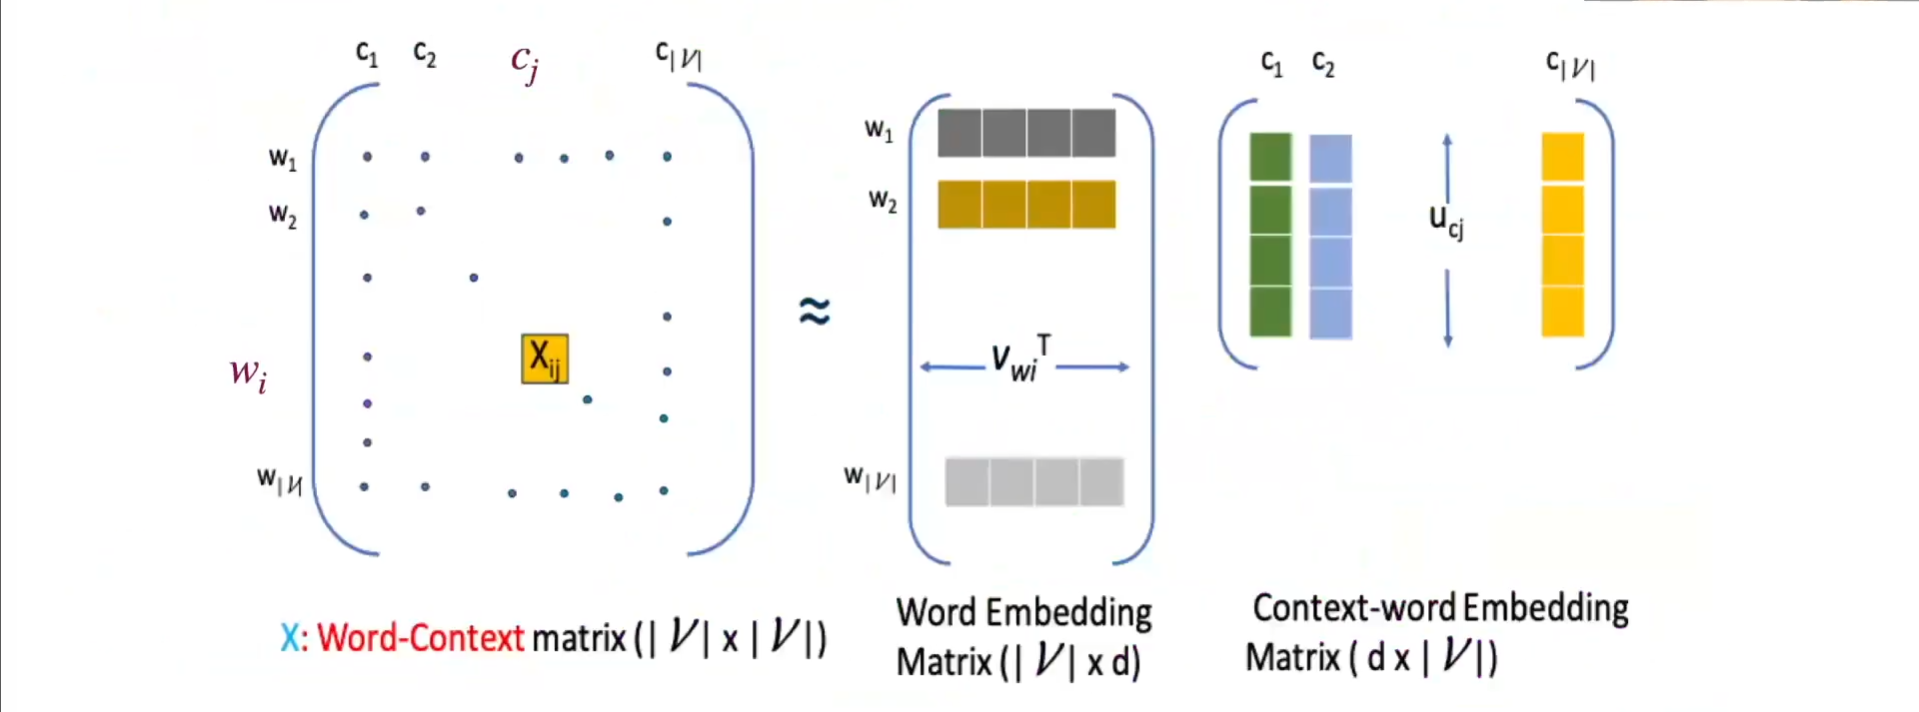

---

## 3. Thiết lập Mục tiêu: Định hình Ngữ nghĩa

Mục đích của việc tạo ra $V$ và $U$ là để khi lấy một hàng của $V$ nhân vô hướng với một cột của $U$, kết quả sinh ra phải xấp xỉ với logarit của số lần chúng đi chung trong thực tế:

$$
v_i^T \cdot u_j \approx \log(X_{ij})
$$

**Sức mạnh của tích vô hướng:** Nó đo lường sự cộng hưởng đặc trưng giữa hai từ. Bản chất của phép nhân này là lấy (đặc trưng 1 của từ $i$ $\times$ đặc trưng 1 của từ $j$) + (đặc trưng 2 $\times$ đặc trưng 2)... Nếu hai từ có chung nhiều tính chất ẩn (cùng có số lớn ở các cột giống nhau), tổng cộng dồn sẽ ra một con số rất lớn, thể hiện sự liên kết chặt chẽ.

**Sức mạnh của hàm $\log$:** Nó làm hai nhiệm vụ vĩ đại. Thứ nhất, nó nén các khoảng cách khổng lồ của tần suất (ví dụ: biến 1 triệu thành 6, biến 100 thành 2) để máy tính không bị "ngợp". Thứ hai, nó biến tỷ lệ xác suất đồng xuất hiện (một khái niệm thống kê) thành khoảng cách hình học giữa các vector (phép trừ). Nhờ $\log$, khi máy tính cộng/trừ các mũi tên vector, nó thực chất đang mô phỏng lại logic tư duy của con người.

---

## 4. Từ Ý tưởng Phân tích Ma trận đến Hàm Mất Mát (Loss Function)

Quá trình xây dựng hàm mất mát trong GloVe không phải là ngẫu nhiên, mà là sự phát triển có chủ đích từ một ý tưởng toán học thô sơ thành một công cụ học máy hoàn chỉnh. Dựa trên hình ảnh "image\_026582.jpg", chúng ta có thể thấy rõ con đường hình thành này qua 3 bước:

### Bước 4.1: Khởi nguồn ý tưởng (Dòng 1)

Ý tưởng cốt lõi của GloVe được biểu diễn bằng phương trình:

$$
X_{ij} \cong \exp(v_{w_i}^T u_{c_j})
$$

Nó mang ý nghĩa: Tần suất đồng xuất hiện của hai từ xấp xỉ bằng hàm mũ của tích vô hướng hai vector đặc trưng. Tuy nhiên, để máy tính có thể xử lý, người ta phải biến đổi nó thành dạng tuyến tính bằng cách lấy logarit tự nhiên ($\log$) ở cả hai vế. Lúc này, phương trình trở thành mục tiêu dự đoán: $v_{w_i}^T u_{c_j} \approx \log(X_{ij})$.

### Bước 4.2: Bài toán tối ưu hóa cơ bản (Dòng 2)

Để máy tính biết mình đang đoán sai bao nhiêu, người ta thiết lập một bài toán tối ưu hóa tổng quát (Optimization Problem):

$$
\min_{v_w, u_c} \left\| V_w U_c - \log(X) \right\|_F^2
$$

Biểu thức này sử dụng chuẩn Frobenius ($\left|...\right|_F$) để tính tổng bình phương sai lệch giữa ma trận dự đoán ($V_w U_c$) và ma trận thực tế ($\log(X)$). Chữ $\min$ yêu cầu hệ thống phải tìm cách điều chỉnh $V$ và $U$ sao cho tổng sai số này đạt mức nhỏ nhất. Tuy nhiên, biểu thức này đánh giá mọi ô trong ma trận là công bằng như nhau, điều này cực kỳ sai lầm trong ngôn ngữ tự nhiên.

### Bước 4.3: Hoàn thiện Hàm Mất Mát $J$ thực tế (Dòng 3)

Để giải quyết bài toán của ngôn ngữ, GloVe phá vỡ phương trình tổng quát thành từng phần tử và bổ sung thêm các "vũ khí" toán học, tạo ra hàm chi phí $J$ hoàn chỉnh:

$$
J = \sum_{i,j=1}^{\lvert V\rvert} f(X_{ij}) \left( v_{w_i}^T u_{c_j} + b_i + \tilde{b}_j - \log(X_{ij}) \right)^2
$$

**Lấy hiệu bình phương:** Lấy kết quả máy tự đoán ($v_{w_i}^T u_{c_j}$) cộng với các Bias, rồi trừ đi dữ liệu thực tế ($\log X_{ij}$) để ra sai số. Bình phương lên để triệt tiêu dấu âm và phạt thật nặng những dự đoán sai lệch nhiều.

**Hệ số chệch (Bias) $b_i, \tilde{b}_j$:** Đây là một sáng kiến xuất sắc. Mỗi từ trong ngôn ngữ có một tần suất xuất hiện tự nhiên (ví dụ từ "là" xuất hiện ở mọi nơi). Hai hệ số này sinh ra để "hấp thụ" cái tần suất cơ bản đó, gánh vác phần "số lượng". Nhờ vậy, phần "chất lượng" (ý nghĩa tinh khiết) được dồn trọn vẹn vào các vector $v$ và $u$, giúp chúng không bị bóp méo.

**Hàm trọng số $f(X_{ij})$:** Là "bộ lọc công bằng" quyết định xem máy tính nên dành bao nhiêu phần trăm sự chú ý cho mỗi cặp từ:

$$f(X_{ij}) = \begin{cases} \left( \frac{X_{ij}}{x_{max}} \right)^\alpha & \text{nếu } X_{ij} < x_{max} \\ 1 & \text{nếu } X_{ij} \ge x_{max} \end{cases}$$

- **Khi $X_{ij} = 0$:** Hàm $f(x) = 0$, giúp máy tính bỏ qua ngay lập tức các cặp từ không bao giờ gặp nhau, tránh được lỗi $\log(0)$ gây sập hệ thống. 
- **Khi $X_{ij}$ nhỏ:** Trọng số $f(x)$ được kích thích tăng theo cấp số nhân ($\alpha = 0.75$), ép hệ thống phải chú ý đến các từ hiếm (như thuật ngữ y khoa). 
- **Khi $X_{ij}$ cực lớn:** Hàm $f(x)$ bị "khóa trần" ở mức 1. Nó giới hạn quyền lực của các từ thông dụng, ngăn không cho chúng thao túng toàn bộ quỹ thời gian tính toán của mô hình. 

---

## 5. Quy trình Tối ưu hóa (Giải bài toán)

Máy tính không dùng công thức giải ra đáp án ngay, mà áp dụng phương pháp "mò mẫm có định hướng" (Gradient Descent):

**Khởi tạo ngẫu nhiên:** Hệ thống điền những con số vô nghĩa, ngẫu nhiên vào tất cả các ô trong ma trận $V$ và $U$.

**Đo lường sai số:** Tính tổng hàm $J$. Vì ban đầu đoán bừa, sai số lúc này sẽ là một con số khổng lồ.

**Điều chỉnh (Cập nhật trọng số):** Hệ thống dùng đạo hàm (Gradient) để đo độ dốc của hàm mất mát. Đạo hàm sẽ chỉ cho máy tính biết: "Nếu tăng số này ở ma trận $V$ lên một chút, và giảm số kia ở ma trận $U$ xuống một chút, thì sai số $J$ sẽ giảm đi".

**Hội tụ:** Quá trình tinh chỉnh từng chút một này lặp đi lặp lại hàng triệu vòng (Epochs). Đến khi hàm $J$ chạm đến đáy (giá trị nhỏ nhất, không thể giảm thêm được nữa), máy tính sẽ dừng lại. Lúc này, nó đã tìm ra bộ số tối ưu nhất cho $V$ và $U$.

---

## 6. Thu hoạch: Word Embeddings Hoàn chỉnh

Sau khi tối ưu xong, thay vì chỉ lấy một ma trận, mô hình GloVe thực hiện một thủ thuật cuối cùng vô cùng tinh tế:

**Kết hợp hai ma trận:** Nó cộng trực tiếp vector mục tiêu và vector ngữ cảnh của cùng một từ lại với nhau:

$$
w_{final} = v_i + u_i
$$

**Kết quả:** Tại sao lại cộng? Về lý thuyết, do ma trận $X$ đối xứng, $V$ và $U$ có cấu trúc tương đương nhau, chúng chỉ khác nhau ở các con số khởi tạo ngẫu nhiên ban đầu. Việc cộng gộp này hoạt động như một màng lọc Ensemble, giúp triệt tiêu các nhiễu âm/dương sinh ra trong lúc huấn luyện. Ma trận tổng thu được chính là bộ Word Embeddings (Vector từ nhúng) dày đặc, chứa đựng toàn bộ sự liên kết ngữ nghĩa tinh vi của ngôn ngữ, sẵn sàng cung cấp cho các ứng dụng AI như dịch máy hay chatbot.

# VI. FastText

## **1. Khởi nguồn dữ liệu: Đơn vị từ vựng phụ (Subword) và Character N-grams**

Nếu GloVe hay Word2Vec nhìn nhận mỗi từ là một "nguyên tử" độc lập không thể chia cắt, thì FastText (được phát triển bởi Facebook AI) tiếp cận ngôn ngữ ở cấp độ cấu trúc hạ nguyên tử: các ký tự.

**Bản chất:** FastText không chỉ học dựa trên từ nguyên vẹn, mà phân rã mỗi từ thành các chuỗi ký tự ngắn hơn gọi là character n-grams. Để phân biệt đâu là n-gram bên trong từ và đâu là cả một từ, FastText thêm hai ký hiệu đặc biệt < (bắt đầu) và > (kết thúc).

**Ví dụ thực tế:** Với từ "apple" và n-gram bằng 3 (tri-grams), máy tính sẽ chia nó thành tập hợp:

$$
<ap,\ app,\ ppl,\ ple,\ le>
$$

và từ gốc <apple>

**Điểm yếu chí mạng của mô hình cũ được giải quyết:** Trong Word2Vec hay GloVe, các từ "máy_tính", "máy_bay", "máy_cày" hoàn toàn xa lạ với nhau ở cấp độ vector ban đầu. Hơn nữa, nếu một từ bị viết sai chính tả (ví dụ: "mấy_tính") hoặc từ hiếm, mô hình cũ sẽ "mù tịt" và gán cho nó vector <UNK> (Unknown). FastText phá vỡ rào cản này vì "máy_tính" và "mấy_tính" chia sẻ một lượng lớn các n-gram giống hệt nhau (như tín, ính, nh>).Sức mạnh của FastText giúp nó xử lý xuất sắc các ngôn ngữ có hình thái học phức tạp (như tiếng Việt, tiếng Đức, tiếng Ả Rập), nơi các từ được cấu tạo từ nhiều tiền tố, hậu tố hoặc từ ghép.

---

## **2. Sự phân thân của biểu diễn: Sinh ra Ma trận $Z$ và $V$**

Tương tự Word2Vec, FastText trong một câu văn cũng phân định rõ **"từ đích"** (target word) và **"từ ngữ cảnh"** (context words).

Tuy nhiên, FastText định nghĩa hai ma trận nhúng hoàn toàn khác biệt để xử lý cấu trúc hạ nguyên tử này: **Ma trận $Z$ dành cho các n-grams (cấu thành từ đích) và Ma trận $V$ dành cho các từ ngữ cảnh.**

**(Giải thích chi tiết cấu tạo ma trận):**

- **Ma trận Z (Kích thước $G \times N$):** Trong đó $G$ là tổng số lượng tất cả các n-gram có thể có trong tập dữ liệu (thường được băm - hashing xuống một con số cố định như 2 triệu để tiết kiệm RAM). Mỗi hàng đại diện cho một n-gram duy nhất (ví dụ: `học`). Mỗi cột là một chiều đặc trưng ẩn. Sau khi huấn luyện, ma trận $Z$ chính là kho tàng cốt lõi để lắp ghép ra bất kỳ Word Embedding nào.
- **Ma trận V (Kích thước $N \times V$):** Trong đó $V$ là kích thước từ điển (từ nguyên vẹn). Mỗi cột đại diện cho một từ duy nhất khi nó đóng vai trò là "Từ ngữ cảnh". FastText **không** phân rã n-gram cho từ ngữ cảnh nhằm tiết kiệm tối đa chi phí tính toán. Ma trận V chỉ là "giàn giáo" phục vụ quá trình huấn luyện và thường bị vứt bỏ sau đó.

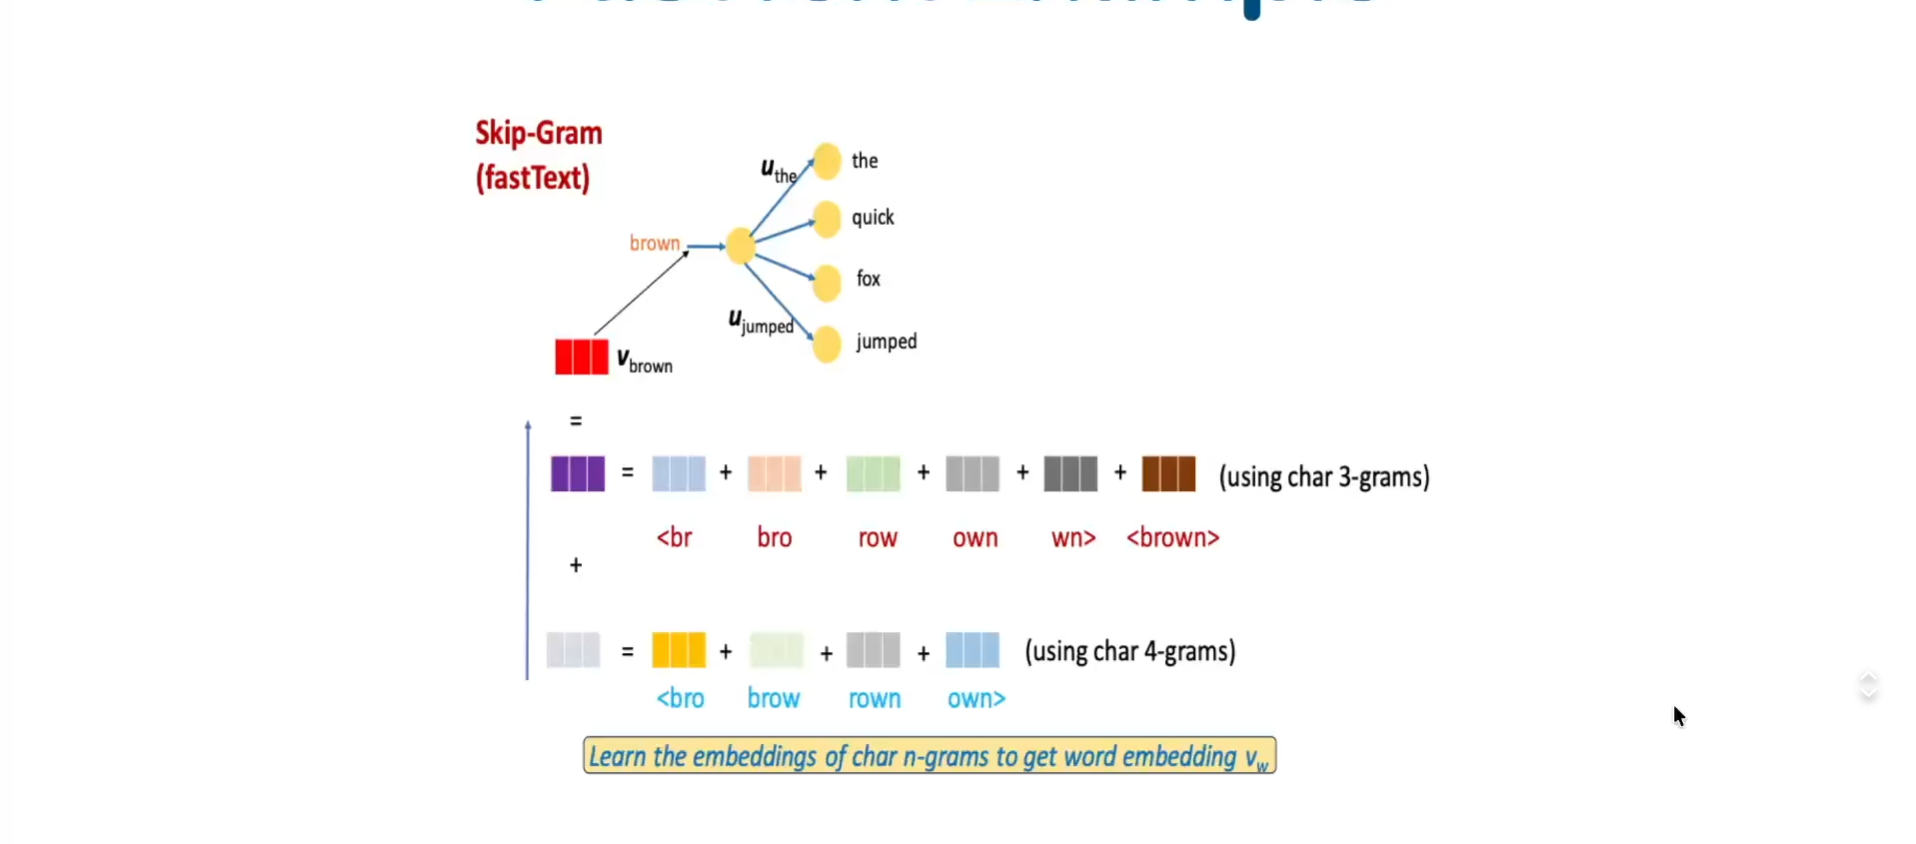

## **3. Vấn đề cốt lõi thực tế: Hashing Trick và Hiện tượng Đụng độ (Collision)**

Về lý thuyết, mỗi n-gram cần một ID riêng. Nhưng trong thực tế, số lượng chuỗi n-gram sinh ra từ một tập dữ liệu lớn là vô hạn (hàng trăm triệu tổ hợp). Nếu cấp ID trực tiếp, hệ thống sẽ sụp đổ vì tràn RAM.

### **3.1. Thuật toán Hashing (Băm)**

FastText khắc phục bằng cách thiết lập số lượng hàng trong ma trận $Z$ ở một mức cố định (ví dụ: $G = 2.000.000$ buckets). Mỗi khi đọc một n-gram (ví dụ: <họ), thay vì tra từ điển, nó đưa chuỗi này qua một hàm băm (như Fowler-Noll-Vo) để nhổ ra một con số ngẫu nhiên cố định từ $1$ đến $2.000.000$. Con số này chính là ID ngăn chứa (hàng) của n-gram đó trong ma trận $Z$.

### **3.2. Hiện tượng Đụng độ N-gram (Collision)**

Vì số lượng n-gram thực tế lớn hơn rất nhiều so với 2 triệu buckets, chắc chắn nhiều n-gram hoàn toàn khác nhau (ví dụ: <ap của từ "apple" và xyz của từ "xy-lanh") sẽ bị hàm băm ném chung vào một ID (ví dụ: ID = 150).

Điều này dẫn đến việc: Dòng trọng số số 150 sẽ liên tục bị kéo về hướng "trái cây" vào buổi sáng, và bị kéo về hướng "y tế" vào buổi chiều. Ngăn chứa này bị nhiễu loạn ý nghĩa.

### **3.3. Tại sao FastText không sụp đổ vì Đụng độ?**

FastText sống sót và giữ được độ chính xác tuyệt đối nhờ hai phép màu của toán học không gian:

**Định lý Triệt tiêu nhiễu đa chiều (Vector Cancellation):** Vector của từ "apple" không chỉ phụ thuộc vào ngăn 150 bị nhiễu. Nó là tổng của rất nhiều ngăn khác (của app, ppl, ple>). Nếu các ngăn này vô tình đụng độ với các chủ đề rác khác (như thể thao, tài chính, pháp luật), thì các lực nhiễu này sẽ trỏ về những hướng hỗn loạn, ngẫu nhiên trong không gian $300$ chiều. Khi cộng gộp lại, các nhiễu ngẫu nhiên này tự triệt tiêu lẫn nhau (tổng bằng 0). Ngược lại, tín hiệu cốt lõi "trái cây" là điểm chung duy nhất được cộng hưởng qua mọi n-gram chuẩn xác, đè bẹp hoàn toàn phần nhiễu.

**Toán học Xác suất (Statistical Improbability):** Xác suất để toàn bộ các n-gram cấu thành nên từ "apple" đều xui xẻo đụng độ với các n-gram của cùng một từ khác (tạo ra nhiễu có hệ thống) là một con số nhỏ bé đến mức tiệm cận 0.

---

## **4. Thiết lập Mục tiêu: Hàm chấm điểm (Scoring Function)**

Khi xem xét một từ đích $w$ đi cùng một từ ngữ cảnh $c$, FastText không dùng 1 vector đơn lẻ cho $w$. Thay vào đó, nó thiết lập đại diện của $w$ tại tầng ẩn ($h_w$) bằng cách **cộng gộp (Summation)** toàn bộ vector của các n-gram cấu thành nên nó:

$$
h_{w} = \sum_{g \in G_{w}} z_{g}
$$

Sau đó, điểm số tương đồng (Score) giữa từ đích và từ ngữ cảnh được tính bằng tích vô hướng giữa vector tổng hợp này và vector ngữ cảnh:

$$
Score(w, c) = h_{w}^{T} v_{c} = \left( \sum_{g \in G_{w}} z_{g} \right)^{T} v_{c}
$$

Nhờ tính chất cộng tuyến tính này, ý nghĩa của một từ được quyết định bởi tổng hòa ý nghĩa của mọi tiền tố, hậu tố và gốc từ tạo ra nó.

---

## **5. Từ Điểm số đến Hàm Mất Mát (Loss Function): Lấy mẫu âm**

Để tối ưu hóa, FastText không bắt máy tính đoán đúng 100% từ ngữ cảnh giữa hàng triệu từ (tính Softmax toàn cục là bất khả thi). Thay vào đó, nó dùng kỹ thuật Lấy mẫu âm (Negative Sampling).

### **Bài toán tối ưu hóa cơ bản**

Mục tiêu là biến bài toán từ "dự đoán từ gì" thành "dự đoán Đúng/Sai (Binary Classification)". Với một từ mục tiêu $w$:

Nó đi cùng từ ngữ cảnh thực tế $c$ -> Máy phải học cách đẩy xác suất này lên 1 (True).

Máy bốc bừa $K$ từ ngẫu nhiên trong từ điển (gọi là $n_i$, ví dụ "bàn", "ghế") -> Máy phải học cách ép xác suất này về 0 (False).

### **Hàm Mất Mát $J$ hoàn chỉnh**

Hàm chi phí toán học mà FastText phải tối thiểu hóa cho một cặp (mục tiêu $w$, ngữ cảnh $c$) được viết như sau:

$$
J = -\log\big(\sigma(s(w, c))\big) - \sum_{i=1}^K \log\big(\sigma(-s(w, n_i))\big)
$$

**Hàm Sigmoid $\sigma(x)$:** Ép điểm số $s(w, c)$ (vốn có thể trải từ âm vô cùng đến dương vô cùng) về một dải từ 0 đến 1, đóng vai trò như xác suất.

**Thành phần thứ nhất (Positive Sample):** Trừ đi logarit của xác suất đúng. Điểm số $s(w, c)$ càng cao, xác suất càng gần 1, $\log(1) = 0$, nghĩa là sai số (loss) gần như không có.

**Thành phần thứ hai (Negative Samples):** Máy tính sẽ phạt những từ nhiễu $n_i$. Dấu âm trong $\sigma(-s(w, n_i))$ ép hệ thống phải kéo điểm số của các cặp từ không liên quan này xuống mức thấp nhất có thể.

---
## 6. Tổng Kết 
**1. Lớp Đầu Vào (Input Layer): Chuẩn bị và Rút trích ID**

Khi mô hình đọc đến một từ đích $w$ (ví dụ: "apple"), nó không đưa toàn bộ từ này vào mạng ngay, mà sinh ra tập hợp các mảnh n-gram $G_w$.

Các chuỗi ký tự này được đẩy qua hàm Hashing để chuyển đổi thành một mảng các số nguyên (ID) tương ứng với các "ngăn chứa" được quy định trước (ví dụ: thu được mảng ID [150, 8990, 45000]).

---

 **2. Lớp Ẩn (Hidden Layer): Lan truyền xuôi và Cộng gộp**

Lớp ẩn của FastText chứa Ma trận N-gram $Z$, đóng vai trò là bộ trọng số đầu vào $W_{in}$ của mạng nơ-ron.

Dựa vào mảng ID từ đầu vào, mạng nơ-ron hoạt động như một hệ thống "tra bảng". Nó trích xuất trực tiếp các vector $z_g$ có số chiều $d$ tương ứng từ ma trận $Z$.

**Hoạt động cốt lõi:** Lớp ẩn này hoàn toàn không sử dụng hàm kích hoạt phi tuyến (như ReLU hay Tanh). Nó áp dụng một phép biến đổi tuyến tính bằng cách cộng gộp (Summation) tất cả các vector n-gram vừa trích xuất lại thành một vector nén duy nhất:

$$
h_w = \sum_{g} z_g
$$

Đây là đại diện chính thức của từ đích.

---

 **3. Lớp Đầu Ra (Output Layer): Tính toán Xác suất**

Lớp này chứa Ma trận Ngữ cảnh $V$, đóng vai trò là bộ trọng số đầu ra $W_{out}$.

Vector tổng hợp $h_w$ tiếp tục tiến lên và được nhân vô hướng (Dot product) với vector của từ ngữ cảnh thực tế $v_c$ cùng các vector của nhóm từ nhiễu $v_{n_i}$ (Negative Samples).

Tại điểm cuối cùng, các giá trị thô này mới được đẩy qua hàm kích hoạt Sigmoid $\sigma(x)$, biến đổi chúng thành các điểm số xác suất từ $0$ đến $1$ để dự đoán xem hai từ có thực sự đi cùng nhau hay không.

---

 **4. Lan truyền ngược (Backpropagation): Cập nhật Trọng số**

Mạng nơ-ron tính toán độ chênh lệch (Loss) giữa xác suất vừa dự đoán và đáp án thực tế (ép từ đúng về 1, từ sai về 0).

Đạo hàm (Gradient) của sai số này được tính và cập nhật ngay lập tức cho các vector ngữ cảnh tại Ma trận $V$.

Dòng thác sai số tiếp tục chảy ngược về lớp ẩn. Tín hiệu tinh chỉnh được "dội" trực tiếp và chia đều vào đúng các ID ngăn chứa đã được mở ở Bước 2. Các tham số trong Ma trận $Z$ được dịch chuyển một chút để các n-gram này mang ý nghĩa sắc nét hơn cho những lần dự đoán sau.

---

 **6. Thu hoạch: Vector từ nhúng và Sức mạnh Vô cực (OOV)**

Sau khi quá trình huấn luyện hoàn tất, ma trận ngữ cảnh $V$ thường bị vứt bỏ. Quả ngọt thu được là Ma trận $Z$ chứa vector của hàng triệu n-gram.

 **Kết hợp Vector**

Khi cần lấy Word Embedding cho một từ $w$ bất kỳ, FastText thực hiện phép cộng đơn giản:

$$
Vector(w) = \frac{1}{\lvert G_w \rvert} \sum_{g \in G_w} z_g
$$

### **Sức mạnh phá vỡ giới hạn OOV (Out-Of-Vocabulary)**

Đây là thành tựu vĩ đại nhất của FastText. Nếu ngày mai trên mạng xuất hiện một từ lóng mới tinh như "trẻ_trâu_hóa", GloVe hay Word2Vec sẽ báo lỗi vì từ này không có trong từ điển lúc huấn luyện. Nhưng FastText thì mỉm cười. Nó lôi từ đó ra băm nhỏ thành <tr, trẻ, rẻ_, _tr, trâ, râu, v.v... Sau đó, nó gom các vector n-gram đã học từ "trẻ_em", "con_trâu", "tiến_hóa" cộng lại. Kết quả là nó tổng hợp ra được một vector mới tinh, bao hàm cực kỳ chính xác ý nghĩa của một từ mà nó chưa từng nhìn thấy bao giờ.

# VII. BPE

## 1. Bản chất cốt lõi: Tiền xử lý thay vì Tối ưu hóa

Khác với các mô hình biểu diễn cổ điển như Word2Vec hay FastText (vốn là các mạng nơ-ron thu nhỏ tự học không gian vector thông qua hàm mất mát và lan truyền ngược), Byte-Pair Encoding (BPE) là một thuật toán thống kê thuần túy có nguồn gốc từ kỹ thuật nén dữ liệu truyền thống. Nó hoàn toàn không có ma trận trọng số, không tính toán đạo hàm và không có hàm mất mát (Loss Function).

- **Vai trò "Thợ sơ chế" độc lập:** BPE đóng vai trò là một Tokenizer (Bộ phân tách từ). Nhiệm vụ duy nhất của nó là băm nhỏ văn bản thô thành các mảng mã định danh (ID) gọn gàng, tạo ra dữ liệu đầu vào sạch sẽ trước khi giao cho các mạng nơ-ron khổng lồ (như Transformer trong GPT, LLaMA) thực hiện việc học ngữ nghĩa.
- **Không gian RAM và cấu trúc 1 chiều:** Ở giai đoạn này, dữ liệu không được biểu diễn dưới dạng ma trận không gian đa chiều (2D/3D). Mỗi từ trong quá trình đếm được lưu trữ dưới dạng một **Mảng 1 chiều (1D Array)** chứa các mã số nguyên đại diện cho ký tự (ví dụ chuẩn ASCII). Toàn bộ quá trình thống kê được quản lý nhẹ nhàng bên trong RAM thông qua cấu trúc **Bảng băm (Hash Map)**, giúp hệ thống xử lý hàng tỷ từ mà không bị tràn bộ nhớ.
- **Ví dụ trực quan về ranh giới:** Khi một mô hình AI đọc câu *"Tôi thích AI"*, BPE không dùng toán học hay đạo hàm để thấu hiểu cảm xúc "thích", cũng không quan tâm từ "thích" đứng cạnh từ "Tôi". Nó chỉ mở cuốn từ điển tĩnh của mình và "thái" câu văn thành một chuỗi số khô khan: `[56, 891, 12]`. Công việc của BPE hoàn tất tại đó; dải số này ngay lập tức được chuyển giao cho bộ não mạng nơ-ron phía sau.

## 2. Thuật toán Học từ vựng: Quy trình Gộp (Merge) và Tối ưu hóa RAM

BPE xây dựng một bộ từ điển có kích thước cố định `V` (ví dụ: 50.000 tokens) đi từ dưới lên (Bottom-up) thông qua các bước đếm tần suất tự động. Quá trình này giúp mô hình tự "ngộ" ra cấu trúc hình thái học của ngôn ngữ mà không cần chuyên gia con người can thiệp thiết lập quy tắc ngữ pháp.

### 2.1. Các bước vận hành của thuật toán

- **Khởi tạo cơ sở (Băm nhỏ tận cùng):** BPE bắt đầu bằng cách cắt mọi từ trong tập dữ liệu huấn luyện thành các ký tự đơn lẻ. Đồng thời, nó gắn thêm ký hiệu đặc biệt `</w>` (End-of-word) vào cuối mỗi từ để đánh dấu ranh giới, tạo ra "bức tường thép" ngăn không cho thuật toán gộp nhầm chữ cái cuối của từ đứng trước với chữ cái đầu của từ tiếp theo.
- **Thống kê và Gộp (Vòng lặp tiến hóa):** Máy tính quét qua bảng băm trong RAM để tìm cặp ký tự (hoặc mảnh subword) đứng liền kề xuất hiện nhiều nhất. Cặp vô địch sẽ được gộp lại thành một mảnh mới. Vòng lặp này lặp đi lặp lại hàng vạn lần cho đến khi đạt đủ `V` tokens mục tiêu.
- **Bí kíp tối ưu của lập trình viên (Cập nhật động):** Thay vì duyệt lại toàn bộ hàng triệu từ trong RAM sau mỗi lần gộp (cách làm ngây thơ gây chậm chạp), các kỹ sư sử dụng kỹ thuật **Cập nhật động (Incremental Update)**. Máy tính chỉ tìm đến những từ có chứa cặp ký tự vừa gộp để điều chỉnh điểm số trên bảng xếp hạng tần suất, giúp thuật toán chạy với tốc độ siêu nhanh.

### 2.2. Ví dụ minh họa chi tiết: Thuật toán BPE "tiêu hóa" một câu văn

**Đầu vào thô:** Giả sử hệ thống nhận được một câu văn (đã lược bỏ dấu phẩy để đơn giản hóa):

*"the player plays playing the play"* (Người chơi chơi đùa, đang chơi trò chơi).

**Vòng 0: Tiền phân tách và Khởi tạo RAM**

Hệ thống dùng khoảng trắng để cắt câu văn thành các từ, đếm số lần xuất hiện và bẻ thành các mảng 1 chiều chứa ký tự đơn lẻ. Lúc này, "Bảng tính" trong RAM trông như sau:

- `['t', 'h', 'e', '</w>']` (Tần suất: 2)
- `['p', 'l', 'a', 'y', 'e', 'r', '</w>']` (Tần suất: 1)
- `['p', 'l', 'a', 'y', 's', '</w>']` (Tần suất: 1)
- `['p', 'l', 'a', 'y', 'i', 'n', 'g', '</w>']` (Tần suất: 1)
- `['p', 'l', 'a', 'y', '</w>']` (Tần suất: 1)

  *(Bạn có thể thấy 4 từ sau đều bắt đầu bằng chuỗi ký tự p-l-a-y).*

**Vòng 1: Máy tính lướt RAM tìm vô địch**

- Máy tính quét qua tất cả các hàng và đếm mọi cặp ký tự liền kề.
- Nó phát hiện cặp `('p', 'l')` xuất hiện ở 4 từ cuối. Tổng điểm = `1 + 1 + 1 + 1 = 4` điểm (cao nhất).
- Quyết định gộp: Đập vách ngăn, biến `p` và `l` thành `pl`.

**Vòng 2 & 3: Lặp lại quá trình gộp "dây chuyền"**

- **Vòng 2:** Quét lại RAM, thấy cặp `('pl', 'a')` xuất hiện 4 lần. Lập tức gộp thành `pla`.
- **Vòng 3:** Tiếp tục quét, thấy cặp `('pla', 'y')` xuất hiện 4 lần. Lập tức gộp thành `play`.

**Vòng 4: Trạng thái RAM sau khi tìm ra "Từ gốc"**

Sau 3 vòng gộp liên tiếp, các mảng dữ liệu trong RAM đã bị thu gọn lại một cách thần kỳ:

- `['t', 'h', 'e', '</w>']` (Tần suất: 2)
- `['play', 'e', 'r', '</w>']` (Tần suất: 1)
- `['play', 's', '</w>']` (Tần suất: 1)
- `['play', 'i', 'n', 'g', '</w>']` (Tần suất: 1)
- `['play', '</w>']` (Tần suất: 1) $\rightarrow$ *Từ "play" đứng một mình đã thành một khối hoàn chỉnh.*

> **Ý nghĩa sâu sắc rút ra từ câu văn này:**
>
> Qua ví dụ trên, bạn có thể thấy sự "đáng sợ" của thuật toán thống kê: Máy tính không hề biết tiếng Anh, nhưng nó tự động bóc tách được gốc từ và hậu tố!
>
> - Vì gốc từ `play` xuất hiện quá nhiều lần (dưới nhiều hình thức), nó bị nén lại thành một token duy nhất cực nhanh.
> - Các hậu tố như `er` (chỉ người), `s` (chỉ số nhiều / động từ chia), `ing` (chỉ trạng thái tiếp diễn) bị tách rời ra và đẩy về cuối.
> - Nhờ cơ chế này, nếu sau này AI gặp một từ mới toanh như `"work"`, nó đã có sẵn các "mảnh lego" là `er`, `s`, `ing` trong từ điển để tự động lắp ráp thành `"worker"`, `"works"`, `"working"` mà không cần phải lưu dư thừa các biến thể này vào bộ nhớ.
>

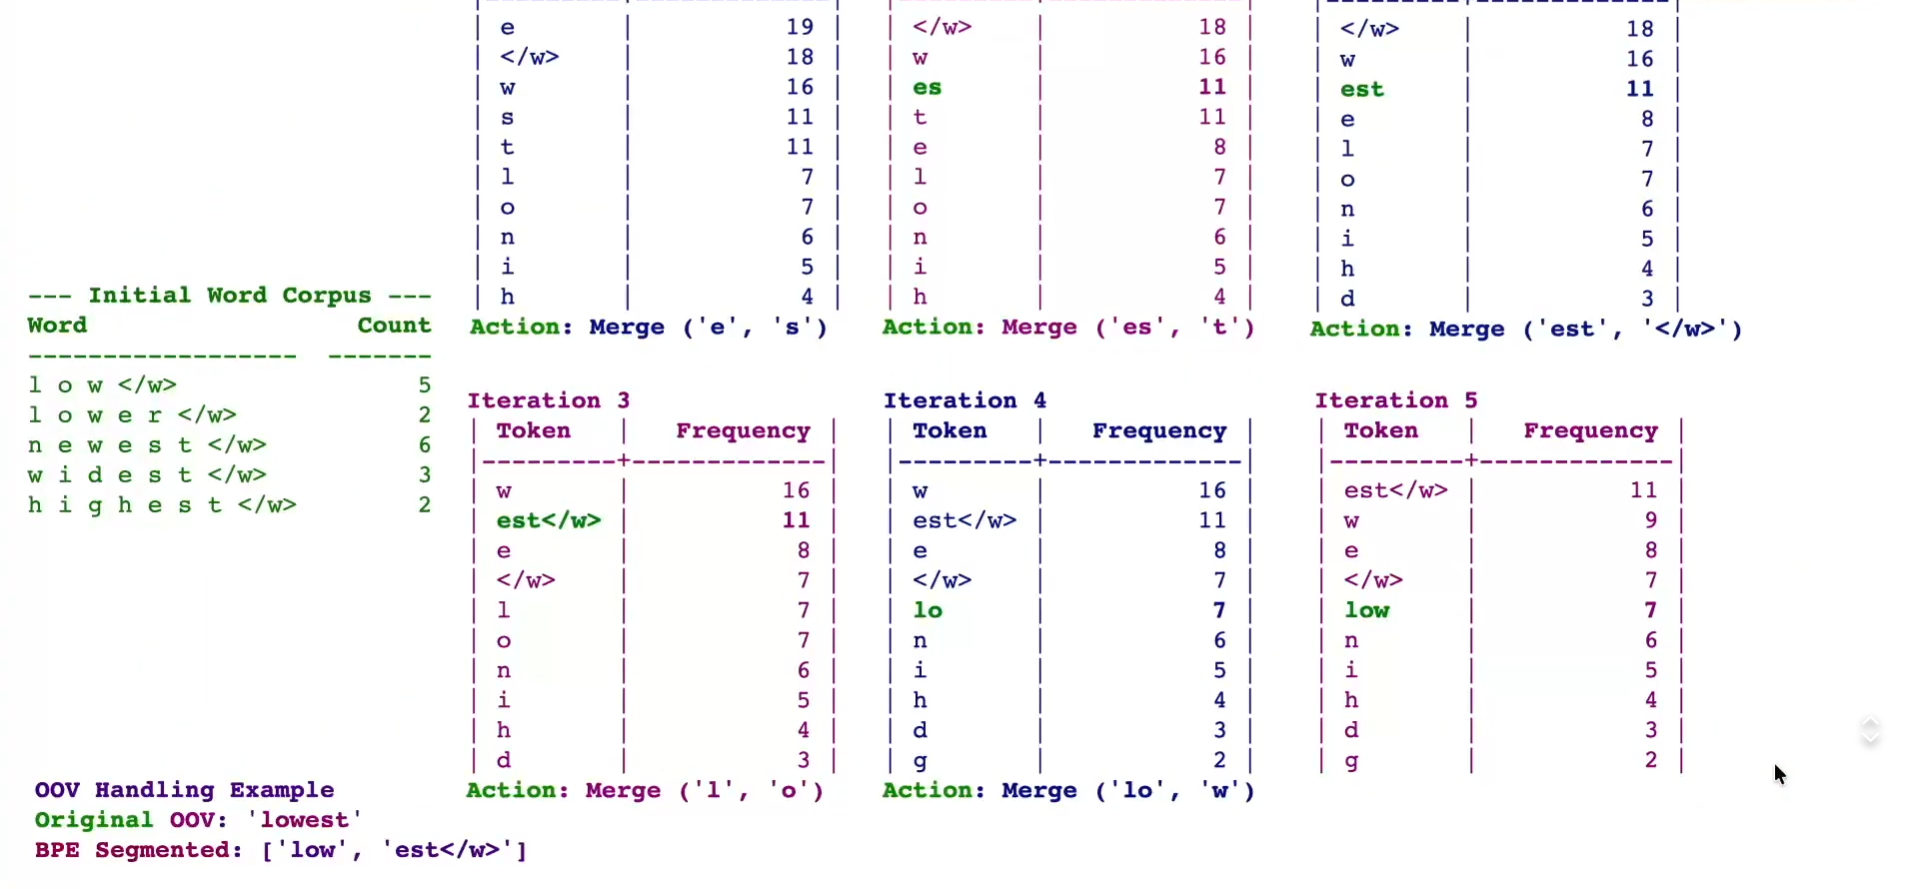


## 3. Tổ chức Đầu vào: Cấp phát ID Tĩnh và Độc lập

Cách BPE tổ chức dữ liệu hoàn toàn đối lập với cơ cấu N-gram cộng gộp (Bag-of-ngrams) của các mô hình cũ như FastText, tạo ra nền móng vững chắc về tính chính xác cho các siêu AI hiện đại.

- **Triệt tiêu Đụng độ (Zero Collision):** FastText dùng thuật toán Hashing ép hàng triệu n-gram vào một số lượng ngăn chứa giới hạn (ví dụ 2 triệu buckets), dẫn đến hiện tượng đụng độ (Collision) khi hai cụm ký tự khác biệt bị ép chung một ID gây nhiễu loạn ý nghĩa. Ngược lại, mỗi token do BPE sinh ra đều được cấp chính xác một mã ID tĩnh, duy nhất trong từ điển. Mã số `450` chỉ trỏ về đúng cụm `tion`, tuyệt đối không trùng lặp hay gây nhiễu.
- **Đầu vào Dạng chuỗi (Sequence) thay vì Khối vô hướng:** Khi gặp một từ phức tạp, hệ thống không rút vector của từng mảnh rồi cộng gộp lại thành một khối hỗn độn mất trật tự. Nó trải dài các mảnh ghép ra theo trục thời gian tuyến tính.
- **Ví dụ minh họa chi tiết:** Xét từ ghép `"Transformer"`. BPE cắt nó thành chuỗi 3 mảnh riêng biệt: `["Trans", "form", "er"]`.
  - Thay vì nhào trộn ý nghĩa của 3 mảnh này ngay từ đầu, BPE cung cấp cho mạng nơ-ron một chuỗi thứ tự rõ ràng: Tại bước thời gian 1 là `"Trans"`, bước 2 là `"form"`, bước 3 là `"er"`.
  - Mạng Transformer phía sau sẽ đọc 3 mảnh này tuần tự, kết hợp với "Vector Vị trí" (Positional Encoding) để hiểu được trật tự cấu trúc ngôn ngữ, bảo toàn hoàn toàn logic ý nghĩa của từ ghép.

## 4. Giải quyết OOV (Out-Of-Vocabulary) và Kỷ nguyên LLM

BPE chính là tiêu chuẩn vàng định hình các mô hình ngôn ngữ lớn như GPT, LLaMA nhờ khả năng cân bằng hoàn hảo giữa dung lượng bộ nhớ và tính bao phủ văn bản.

- **Tối ưu tốc độ với từ thông dụng:** Nếu bẻ mọi chữ thành ký tự đơn lẻ, một câu ngắn cũng tạo ra hàng trăm ID, khiến mạng nơ-ron quá tải vì chuỗi đầu vào quá dài. BPE giải quyết bằng cách giữ nguyên các từ quen thuộc như `"apple"`, `"hello"`, `"the"`, `"và"` thành đúng **1 token duy nhất**. AI có thể "đọc lướt" toàn bộ câu cực nhanh và tiết kiệm bộ nhớ tính toán (RAM/VRAM).
- **Khắc phục hoàn toàn OOV và lỗi chính tả:** Khác với Word2Vec hay các mô hình truyền thống thường trả về mã `<UNK>` (Unknown) khi gặp từ chưa từng học, BPE không bao giờ sụp đổ trước từ mới. Khi gặp từ lạ, nó áp dụng chiến lược phân rã (fallback), bẻ nhỏ dần đến khi tìm được các mảnh subword quen thuộc.
- **Ví dụ minh họa thực tế 1 (Từ lóng mới):** Nếu xuất hiện một từ lóng công nghệ mới tinh là `"ChatGPT_Pro"`, BPE không hề báo lỗi. Nó tự động chặt từ này thành các subword đã được học trong từ điển: `["Chat", "G", "PT", "_", "Pro"]`.
- **Ví dụ minh họa thực tế 2 (Lỗi chính tả):** Nếu người dùng gõ nhầm từ `"banana"` thành `"banaana"`, BPE sẽ bẻ nó thành: `["ban", "a", "ana"]`. Siêu máy tính phía sau dư sức nhìn vào chuỗi ID này để nhận diện và hiểu ý người dùng.